In [1]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
os.makedirs("figures", exist_ok=True)

In [3]:
features = [
    "kstTMass",
    "bVtxCL",
    "bLBSs",
    "bCosAlphaBS",
    "bDCABSs",
    "kstTrkmDCABSs",
    "kstTrkpDCABSs",
]

In [18]:
signal_file = uproot.open("MC.root")["signal_tree"]
background_file = uproot.open("ED.root")["background_tree"]

signal_df = signal_file.arrays(library="pd")
background_df = background_file.arrays(library="pd")

signal_df["label"] = 1
background_df["label"] = 0

df = pd.concat([signal_df, background_df], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(len(signal_df))
print(len(background_df))

2772
57695


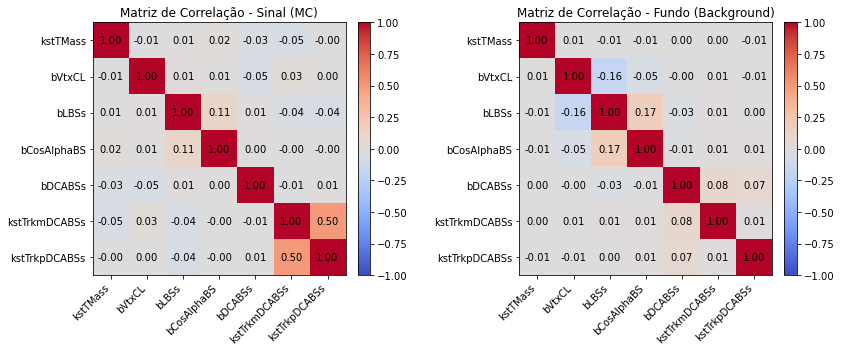

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
corr_signal = signal_df[features].corr()
im1 = plt.imshow(corr_signal, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im1, fraction=0.046, pad=0.04)
plt.title("Matriz de Correlação - Sinal (MC)")
plt.xticks(ticks=np.arange(len(features)), labels=features, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(features)), labels=features)
for i in range(len(features)):
    for j in range(len(features)):
        plt.text(j, i, f"{corr_signal.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.subplot(1, 2, 2)
corr_background = background_df[features].corr()
im2 = plt.imshow(corr_background, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im2, fraction=0.046, pad=0.04)
plt.title("Matriz de Correlação - Fundo (Background)")
plt.xticks(ticks=np.arange(len(features)), labels=features, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(features)), labels=features)
for i in range(len(features)):
    for j in range(len(features)):
        plt.text(j, i, f"{corr_background.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.tight_layout()
plt.savefig("figures/correlation_matrices_signal_background.png")
plt.show()

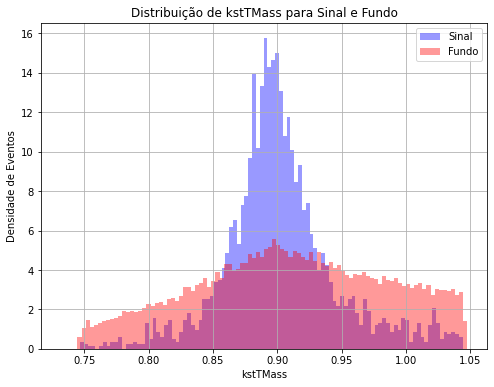

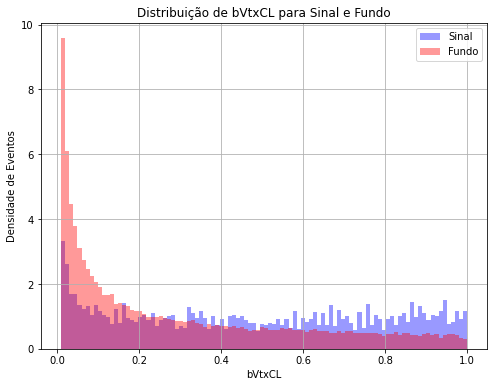

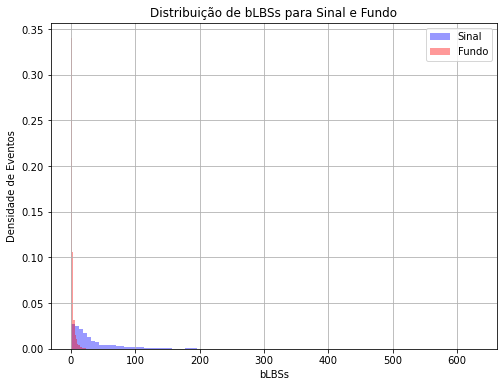

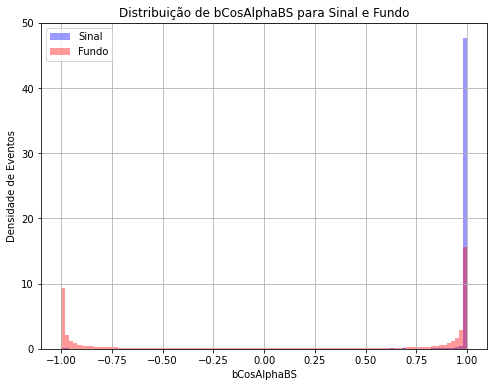

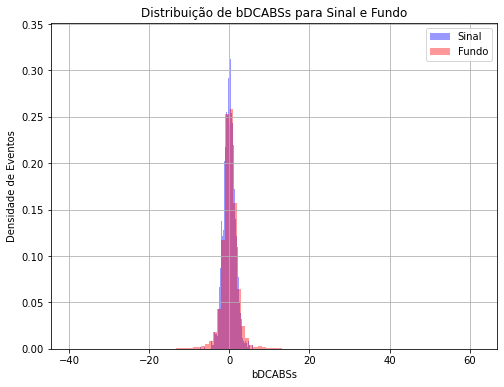

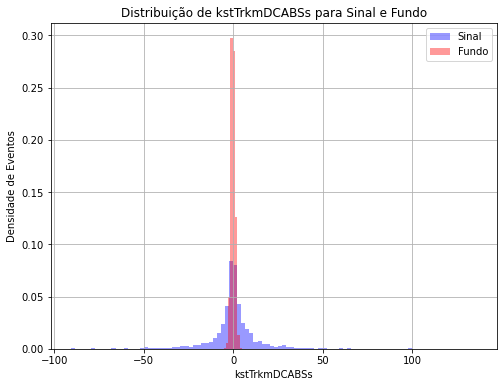

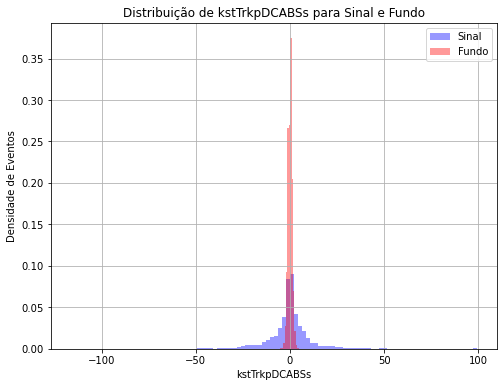

In [6]:
for i, feat in enumerate(features):
    plt.figure(figsize=(8, 6))
    
    plt.hist(signal_df[feat], bins=100, density=True, alpha=0.4, color='blue', label='Sinal')
    plt.hist(background_df[feat], bins=100, density=True, alpha=0.4, color='red', label='Fundo')
    
    plt.xlabel(feat)
    plt.ylabel("Densidade de Eventos")
    plt.title(f"Distribuição de {feat} para Sinal e Fundo")
    plt.legend()
    plt.grid(True) 

    plt.savefig(f"figures/feature_distribution_{feat}.png")
    plt.show() 

In [7]:
X = df[features]
y = df["label"]

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, stratify=y, 
                                                          random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, 
                                                  stratify=y_trainval, random_state=42) 

print(f"Tamanhos dos datasets: treino={len(X_train)}, validação={len(X_val)}, teste={len(X_test)}")
bdt = XGBClassifier(use_label_encoder=False, eval_metric="auc", verbosity=0)

Tamanhos dos datasets: treino=38698, validação=9675, teste=12094


In [8]:
param_grid = {
    "n_estimators": [5, 10, 15, 25, 50, 100, 150, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2,],
    "subsample": [0.2, 0.4, 0.6, 0.8, 1.0],
    "colsample_bytree": [0.2, 0.4, 0.6, 0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=bdt,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2,
)

grid_search.fit(X_train, y_train)

print("Melhores hiperparâmetros encontrados:", grid_search.best_params_)
print(f"Melhor AUC no conjunto de validação cruzada: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 2400 candidates, totalling 12000 fits
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=10, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=10, subsample=0.4; total time=   0.1s
[CV] END colsample_b

[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=10, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=10, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=10, subsa

[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=25, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=25, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=25, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=25, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=25, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=25, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50,

[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.2; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.2; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.2; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=10

[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=7, n_estimators=200, subsample=0.2; total time=   0.5s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=7, n_estimators=200, subsample=0.2; total time=   0.5s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=7, n_estimators=200, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=7, n_estimators=200, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=7, n_estimators=200, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=7, n_estimators=200, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=0.2, learning_rate=0.05, max_depth=3, n_estimators=5, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.05, max_depth=3, n_estimators=5, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.05, max_depth=3, n_estimators

...

[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=50, subsample=0.2; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=50, subsample=0.2; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=50, subsample=0.4; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=50, subsample=0.6; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=50, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=50, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=50, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=100, subsample=0.2; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=100, subsam

[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=200, subsample=0.6; total time=   0.9s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=200, subsample=0.8; total time=   0.8s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=200, subsample=1.0; total time=   0.7s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=5, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=5, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=5, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=5, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=5, subsample=0

[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=150, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=200, subsample=0.4; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=200, subsample=0.4; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=200, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=200, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=200, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=200, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=5, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=5, sub

[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=25, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=25, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=25, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=25, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=50, subsample=0.2; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=50, subsample=0.2; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=50, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=50, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=50, subsampl

Melhores hiperparâmetros encontrados: {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 150, 'subsample': 1.0}
Melhor AUC no conjunto de validação cruzada: 0.9754


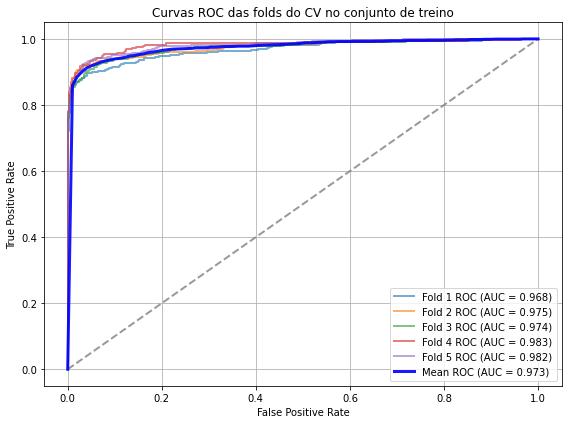

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(8, 6))

for i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model_cv = XGBClassifier(**grid_search.best_params_, use_label_encoder=False, eval_metric="auc", verbosity=0)
    model_cv.fit(X_cv_train, y_cv_train)
    y_cv_proba = model_cv.predict_proba(X_cv_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_cv_val, y_cv_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)

    plt.plot(fpr, tpr, lw=2, alpha=0.6, label=f'Fold {i+1} ROC (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='grey', alpha=0.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)

plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.3f})', lw=3, alpha=0.9)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC das folds do CV no conjunto de treino')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/roc_cv_folds.png")
plt.show()

In [10]:
best_bdt = grid_search.best_estimator_
y_val_proba = best_bdt.predict_proba(X_val)[:, 1]

fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
roc_auc_val = auc(fpr_val, tpr_val)

precision_val, recall_val, _ = precision_recall_curve(y_val, y_val_proba)
prc_auc_val = average_precision_score(y_val, y_val_proba)

print(f"AUC ROC no conjunto de validação: {roc_auc_val:.4f}")
print(f"AUC Precision-Recall no conjunto de validação: {prc_auc_val:.4f}")

AUC ROC no conjunto de validação: 0.9699
AUC Precision-Recall no conjunto de validação: 0.8898


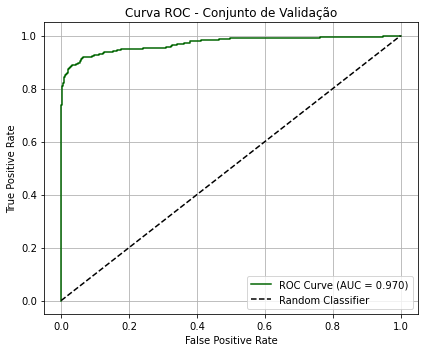

In [21]:
plt.figure(figsize=(6, 5))
plt.plot(fpr_val, tpr_val, label=f"ROC Curve (AUC = {roc_auc_val:.3f})", color="darkgreen")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Conjunto de Validação")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/roc_validation_curve.png")
plt.show()

In [11]:
X_trainval_full = pd.concat([X_train, X_val])
y_trainval_full = pd.concat([y_train, y_val])
best_bdt.fit(X_trainval_full, y_trainval_full)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [12]:
y_test_proba = best_bdt.predict_proba(X_test)[:, 1]
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
roc_auc_test = auc(fpr_test, tpr_test)

precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba)
prc_auc_test = average_precision_score(y_test, y_test_proba)

print(f"AUC ROC no conjunto de teste: {roc_auc_test:.4f}")
print(f"AUC Precision-Recall no conjunto de teste: {prc_auc_test:.4f}")

AUC ROC no conjunto de teste: 0.9800
AUC Precision-Recall no conjunto de teste: 0.8928


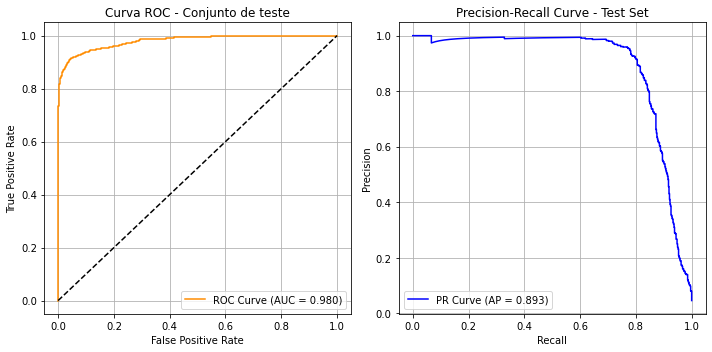

In [13]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_test, tpr_test, label=f"ROC Curve (AUC = {roc_auc_test:.3f})", color="darkorange")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Conjunto de teste")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(recall_test, precision_test, label=f"PR Curve (AP = {prc_auc_test:.3f})", color="blue")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Test Set")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("figures/final_roc_prc_curves.png")
plt.show()

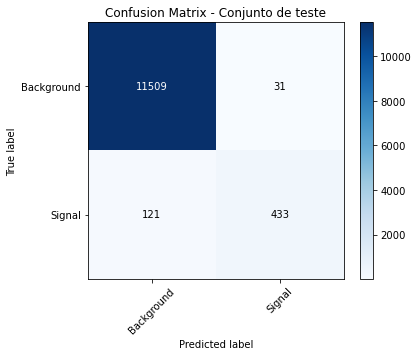

In [14]:
y_test_pred = best_bdt.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Conjunto de teste")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Background", "Signal"], rotation=45)
plt.yticks(tick_marks, ["Background", "Signal"])

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig("figures/final_confusion_matrix.png")
plt.show()

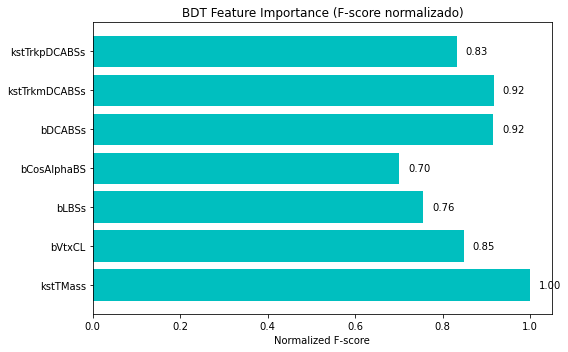

In [15]:
# --- 11. Importância das variáveis ---
fscore = best_bdt.get_booster().get_score(importance_type="weight")
fscore_df = pd.DataFrame.from_dict(fscore, orient="index", columns=["F-score"])
fscore_df = fscore_df.reindex(features).fillna(0)
fscore_df["Normalized"] = fscore_df["F-score"] / fscore_df["F-score"].max()

plt.figure(figsize=(8, 5))
bars = plt.barh(fscore_df.index, fscore_df["Normalized"], color='c')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center', color='black')

plt.xlabel("Normalized F-score")
plt.title("BDT Feature Importance (F-score normalizado)")
plt.tight_layout()
plt.savefig("figures/final_feature_importance.png")
plt.show()

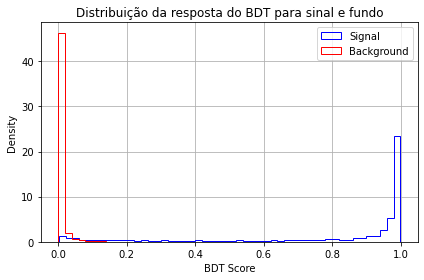

[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=10, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=15, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=15, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=15, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=15, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=15, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=15, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=25, subsample=0.2; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=25, subsampl

In [16]:
df["bdtScore"] = best_bdt.predict_proba(X)[:, 1]

plt.figure(figsize=(6, 4))
bins = 50
plt.hist(df[df["label"] == 1]["bdtScore"], bins=bins, density=True, histtype='step', color='blue', label='Signal')
plt.hist(df[df["label"] == 0]["bdtScore"], bins=bins, density=True, histtype='step', color='red', label='Background')
plt.xlabel("BDT Score")
plt.ylabel("Density")
plt.title("Distribuição da resposta do BDT para sinal e fundo")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/final_bdt_score_distribution.png")
plt.show()

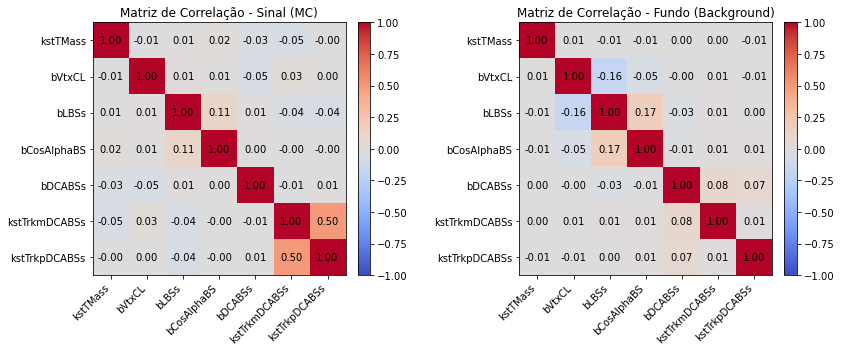

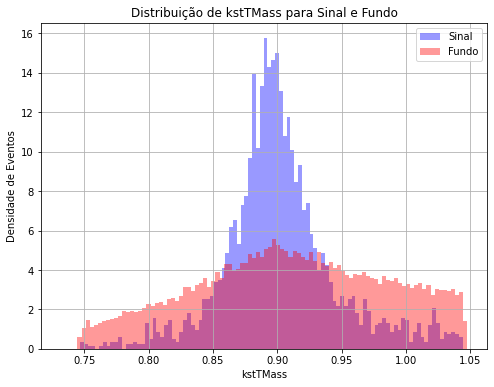

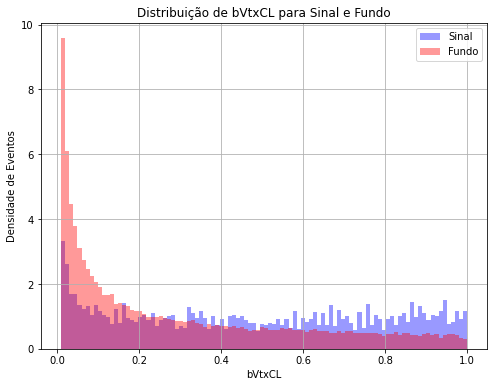

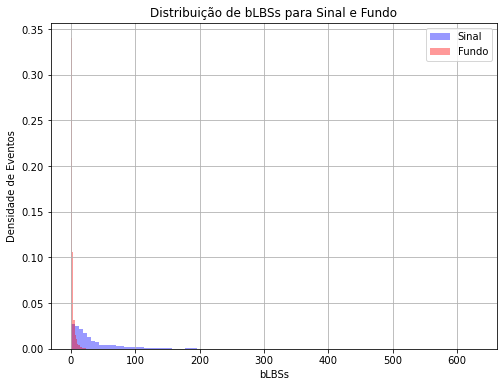

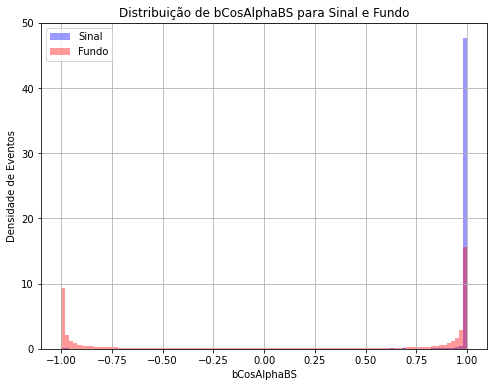

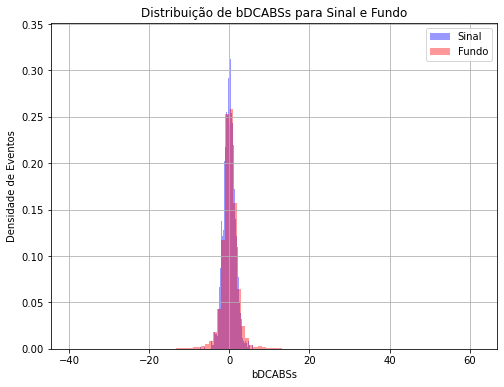

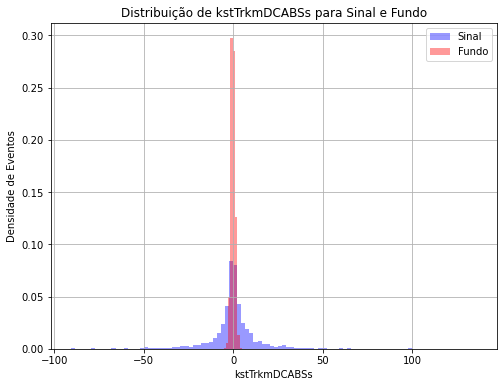

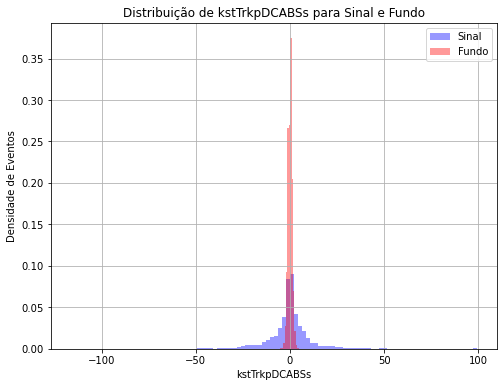

Tamanhos dos datasets: treino=38698, validação=9675, teste=12094
Fitting 5 folds for each of 2400 candidates, totalling 12000 fits
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=10, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_esti

[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=5, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=10, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=10, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=3, n_estimators=10, subsa

[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=25, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=25, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=25, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=25, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=25, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=25, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50,

[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.2; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.2; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=50, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.2; total time=   0.2s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=5, n_estimators=10


[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=7, n_estimators=200, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=7, n_estimators=200, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.2, learning_rate=0.01, max_depth=7, n_estimators=200, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.2, learning_rate=0.05, max_depth=3, n_estimators=5, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.05, max_depth=3, n_estimators=5, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.05, max_depth=3, n_estimators=5, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.05, max_depth=3, n_estimators=5, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.05, max_depth=3, n_estimators=5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.2, learning_rate=0.05, max_depth=3, n_estimators=5, s

...

[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.6; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=150, subsample=0.2; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=150, subsample=0.2; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=150, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=150, subsample=0.6; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=150, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=5, n_estimators=150,

[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=25, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=50, subsample=0.2; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=50, subsample=0.4; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=50, subsample=0.4; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=50, subsample=0.6; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=50, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=50, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=100, subsample=0.2; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=100, subsam

[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=5, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=5, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=5, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=10, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=10, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=10, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=10, subsample=0.6

[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=150, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=200, subsample=0.2; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=200, subsample=0.2; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=200, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=200, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, n_estimators=200, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=5, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=5, sub

[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=25, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=25, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=25, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=25, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=50, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=50, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=50, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=50, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=5, n_estimators=50, subsampl

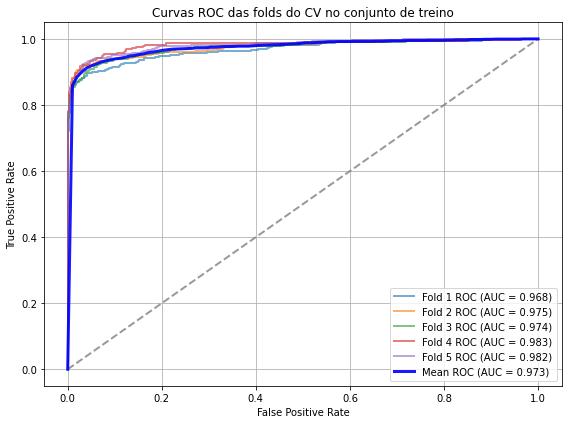

AUC ROC no conjunto de validação: 0.9699
AUC Precision-Recall no conjunto de validação: 0.8898
AUC ROC no conjunto de teste: 0.9800
AUC Precision-Recall no conjunto de teste: 0.8928


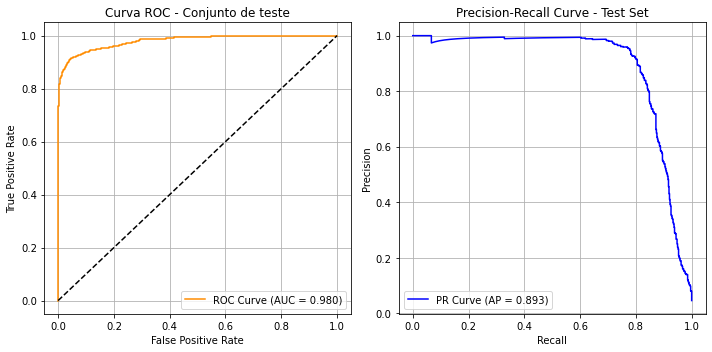

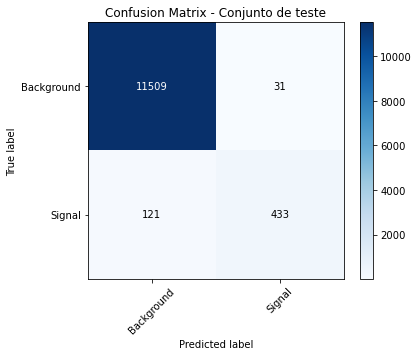

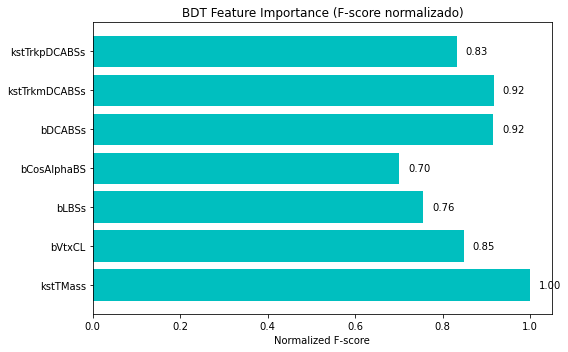

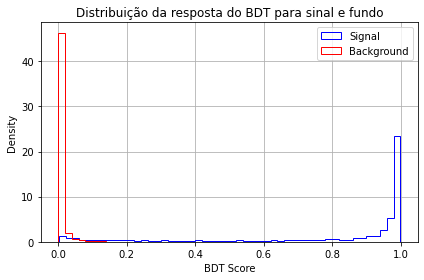

[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=15, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=15, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=15, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=25, subsample=0.2; total time=   0.1s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=25, subsample=0.2; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=25, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=25, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=25, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=25, subsampl

[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=150, subsample=0.6; total time=   0.6s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=150, subsample=0.8; total time=   0.6s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=150, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=150, subsample=1.0; total time=   0.5s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200, subsample=0.2; total time=   0.7s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200, subsample=0.4; total time=   0.8s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200, subsample=0.6; total time=   0.8s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200, subsample=0.8; total time=   0.8s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200,

In [19]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
os.makedirs("figures", exist_ok=True)

features = [
    "kstTMass",
    "bVtxCL",
    "bLBSs",
    "bCosAlphaBS",
    "bDCABSs",
    "kstTrkmDCABSs",
    "kstTrkpDCABSs",
]

signal_file = uproot.open("MC.root")["signal_tree"]
background_file = uproot.open("ED.root")["background_tree"]

signal_df = signal_file.arrays(library="pd")
background_df = background_file.arrays(library="pd")

signal_df["label"] = 1
background_df["label"] = 0

df = pd.concat([signal_df, background_df], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
corr_signal = signal_df[features].corr()
im1 = plt.imshow(corr_signal, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im1, fraction=0.046, pad=0.04)
plt.title("Matriz de Correlação - Sinal (MC)")
plt.xticks(ticks=np.arange(len(features)), labels=features, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(features)), labels=features)
for i in range(len(features)):
    for j in range(len(features)):
        plt.text(j, i, f"{corr_signal.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.subplot(1, 2, 2)
corr_background = background_df[features].corr()
im2 = plt.imshow(corr_background, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im2, fraction=0.046, pad=0.04)
plt.title("Matriz de Correlação - Fundo (Background)")
plt.xticks(ticks=np.arange(len(features)), labels=features, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(features)), labels=features)
for i in range(len(features)):
    for j in range(len(features)):
        plt.text(j, i, f"{corr_background.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.tight_layout()
plt.savefig("figures/correlation_matrices_signal_background.png")
plt.show()

for i, feat in enumerate(features):
    plt.figure(figsize=(8, 6))
    
    plt.hist(signal_df[feat], bins=100, density=True, alpha=0.4, color='blue', label='Sinal')
    plt.hist(background_df[feat], bins=100, density=True, alpha=0.4, color='red', label='Fundo')
    
    plt.xlabel(feat)
    plt.ylabel("Densidade de Eventos")
    plt.title(f"Distribuição de {feat} para Sinal e Fundo")
    plt.legend()
    plt.grid(True) 

    plt.savefig(f"figures/feature_distribution_{feat}.png")
    plt.show() 
    
X = df[features]
y = df["label"]

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, stratify=y, 
                                                          random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, 
                                                  stratify=y_trainval, random_state=42) 

print(f"Tamanhos dos datasets: treino={len(X_train)}, validação={len(X_val)}, teste={len(X_test)}")
bdt = XGBClassifier(use_label_encoder=False, eval_metric="auc", verbosity=0)

param_grid = {
    "n_estimators": [5, 10, 15, 25, 50, 100, 150, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2,],
    "subsample": [0.2, 0.4, 0.6, 0.8, 1.0],
    "colsample_bytree": [0.2, 0.4, 0.6, 0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=bdt,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2,
)

grid_search.fit(X_train, y_train)

print("Melhores hiperparâmetros encontrados:", grid_search.best_params_)
print(f"Melhor AUC no conjunto de validação cruzada: {grid_search.best_score_:.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(8, 6))

for i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model_cv = XGBClassifier(**grid_search.best_params_, use_label_encoder=False, eval_metric="auc", verbosity=0)
    model_cv.fit(X_cv_train, y_cv_train)
    y_cv_proba = model_cv.predict_proba(X_cv_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_cv_val, y_cv_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)

    plt.plot(fpr, tpr, lw=2, alpha=0.6, label=f'Fold {i+1} ROC (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='grey', alpha=0.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)

plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.3f})', lw=3, alpha=0.9)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC das folds do CV no conjunto de treino')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/roc_cv_folds.png")
plt.show()

best_bdt = grid_search.best_estimator_
y_val_proba = best_bdt.predict_proba(X_val)[:, 1]

fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
roc_auc_val = auc(fpr_val, tpr_val)

precision_val, recall_val, _ = precision_recall_curve(y_val, y_val_proba)
prc_auc_val = average_precision_score(y_val, y_val_proba)

print(f"AUC ROC no conjunto de validação: {roc_auc_val:.4f}")
print(f"AUC Precision-Recall no conjunto de validação: {prc_auc_val:.4f}")

X_trainval_full = pd.concat([X_train, X_val])
y_trainval_full = pd.concat([y_train, y_val])
best_bdt.fit(X_trainval_full, y_trainval_full)

y_test_proba = best_bdt.predict_proba(X_test)[:, 1]
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
roc_auc_test = auc(fpr_test, tpr_test)

precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba)
prc_auc_test = average_precision_score(y_test, y_test_proba)

print(f"AUC ROC no conjunto de teste: {roc_auc_test:.4f}")
print(f"AUC Precision-Recall no conjunto de teste: {prc_auc_test:.4f}")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_test, tpr_test, label=f"ROC Curve (AUC = {roc_auc_test:.3f})", color="darkorange")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Conjunto de teste")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(recall_test, precision_test, label=f"PR Curve (AP = {prc_auc_test:.3f})", color="blue")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Test Set")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("figures/final_roc_prc_curves.png")
plt.show()

y_test_pred = best_bdt.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Conjunto de teste")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Background", "Signal"], rotation=45)
plt.yticks(tick_marks, ["Background", "Signal"])

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig("figures/final_confusion_matrix.png")
plt.show()

# --- 11. Importância das variáveis ---
fscore = best_bdt.get_booster().get_score(importance_type="weight")
fscore_df = pd.DataFrame.from_dict(fscore, orient="index", columns=["F-score"])
fscore_df = fscore_df.reindex(features).fillna(0)
fscore_df["Normalized"] = fscore_df["F-score"] / fscore_df["F-score"].max()

plt.figure(figsize=(8, 5))
bars = plt.barh(fscore_df.index, fscore_df["Normalized"], color='c')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center', color='black')

plt.xlabel("Normalized F-score")
plt.title("BDT Feature Importance (F-score normalizado)")
plt.tight_layout()
plt.savefig("figures/final_feature_importance.png")
plt.show()

df["bdtScore"] = best_bdt.predict_proba(X)[:, 1]

plt.figure(figsize=(6, 4))
bins = 50
plt.hist(df[df["label"] == 1]["bdtScore"], bins=bins, density=True, histtype='step', color='blue', label='Signal')
plt.hist(df[df["label"] == 0]["bdtScore"], bins=bins, density=True, histtype='step', color='red', label='Background')
plt.xlabel("BDT Score")
plt.ylabel("Density")
plt.title("Distribuição da resposta do BDT para sinal e fundo")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/final_bdt_score_distribution.png")
plt.show()


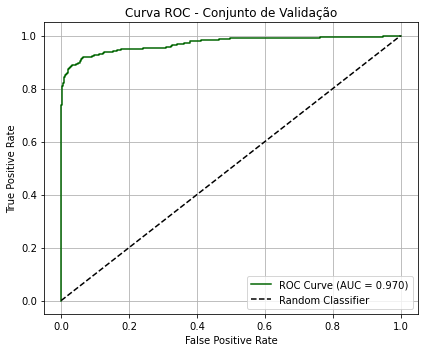

In [20]:
plt.figure(figsize=(6, 5))
plt.plot(fpr_val, tpr_val, label=f"ROC Curve (AUC = {roc_auc_val:.3f})", color="darkgreen")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Conjunto de Validação")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/roc_validation_curve.png")
plt.show()